# Summer's share of national park visits has fallen since 1979, even as summer visits grew

Mohit Kumar, Sikandar Ali

SI 699 mini project. Data: National Park Service Visitor Use Statistics, by-month extract, 1979–2023, distributed by Responsible Datasets in Context.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats

import npdata
import npviz

npviz.apply_style()

# Restrict to parks observed in every year, 1979-2023, so every year compares the same parks.
df_all = npdata.load_by_month()
span = df_all.groupby("ParkName").Year.agg(["min", "max"])
panel_parks = span[(span["min"] <= 1979) & (span["max"] >= 2023)].index
df = df_all[df_all.ParkName.isin(panel_parks)].copy()
excluded = sorted(set(df_all.ParkName) - set(panel_parks))
excluded_share = df_all[df_all.ParkName.isin(excluded)].RecreationVisits.sum() / df_all.RecreationVisits.sum()

national = npdata.monthly_matrix(df, ["Year"])
summer = npdata.summer_share(national)
fit = npdata.trend(summer)
park_share = npdata.summer_share(npdata.monthly_matrix(df, ["ParkName", "Year"])).dropna()

print(f"{df.ParkName.nunique()} parks in the panel; {len(excluded)} excluded "
      f"({excluded_share:.1%} of all recorded visits): {', '.join(excluded)}")
print(f"summer share {summer.loc[1979:1983].mean():.3f} (1979-83) -> {summer.loc[2019:2023].mean():.3f} (2019-23); "
      f"trend {fit.slope*100:+.2f} pp/decade, 95% CI {fit.ci_low*100:+.2f} to {fit.ci_high*100:+.2f}, p = {fit.p_value:.1e}")

55 parks in the panel; 8 excluded (1.8% of all recorded visits): Congaree NP, Gates of the Arctic NP & PRES, Kenai Fjords NP, Kobuk Valley NP, Lake Clark NP & PRES, National Park of American Samoa, New River Gorge NP & PRES, Wrangell-St. Elias NP & PRES
summer share 0.507 (1979-83) -> 0.422 (2019-23); trend -1.66 pp/decade, 95% CI -2.07 to -1.26, p = 7.0e-16


## Claim

**What we mean by de-seasonalization.** We say visitation is *de-seasonalizing* when the share of a year's recreation visits that falls in June, July and August declines over time. We call that share the *summer share*. It measures how visits are spread across the calendar, not how many there are, so it can fall even while summer visits rise. It is a statement about summer specifically: for a desert park whose busiest months are in winter, a falling summer share does not by itself mean that park's calendar became flatter.

**Claim.** National park visits have de-seasonalized since 1979, and they have done it by growing in the rest of the year rather than by shrinking in summer. Across the 55 parks whose records span 1979 to 2023, the summer share fell from 51% of visits in 1979–83 to 42% in 2019–23, a fitted decline of about 1.7 percentage points per decade, while summer visits themselves grew 26%. The endpoint gap is larger than the fitted rate implies because 2021 to 2023 were the lowest years on record.

**Which parks.** Eight of the 63 national parks enter the data after 1979: five Alaska parks in 1982, New River Gorge in 1984, Congaree in 1985 and American Samoa in 2002. Including them would let the national share move just because the set of parks changed, so every result below uses only the 55 parks whose records span all 45 years.

## Analysis

We estimate the change as a trend rather than by comparing two endpoints, because any single pair of years carries its own noise. For each year we pool the visits of all 55 parks, compute the summer share, and fit a straight line on year. The standard errors are Newey-West, which allow neighbouring years to be correlated, as they usually are in an annual series.

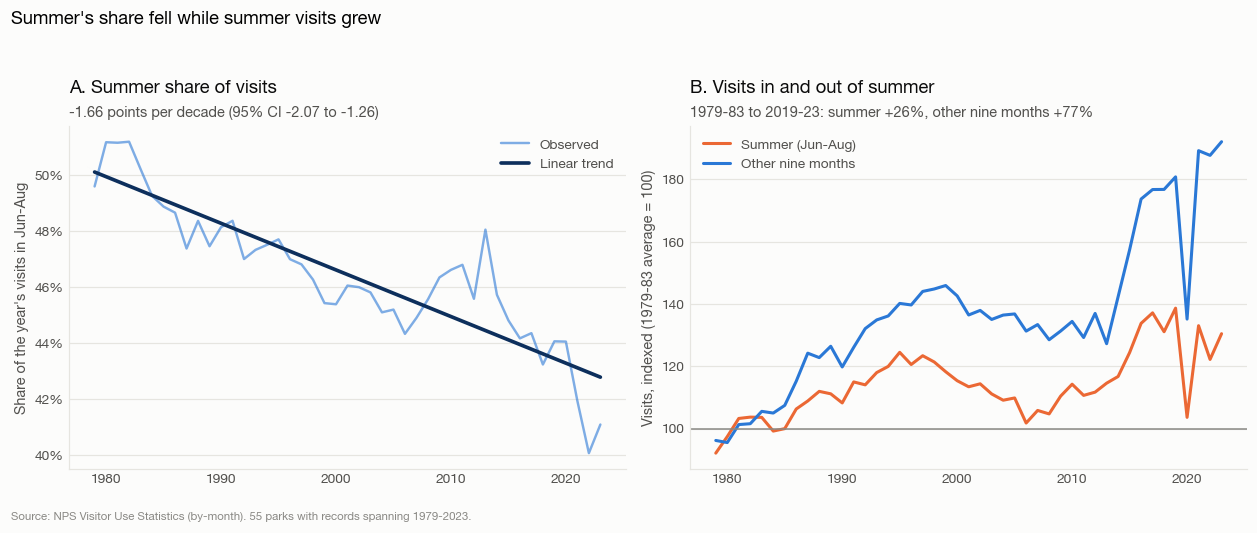

In [2]:
is_summer = df.Month.isin(npdata.SUMMER)
visits = pd.DataFrame({
    "Summer (Jun-Aug)": df[is_summer].groupby("Year").RecreationVisits.sum(),
    "Other nine months": df[~is_summer].groupby("Year").RecreationVisits.sum()})
baseline = visits.loc[1979:1983].mean()
growth = (visits.loc[2019:2023].mean() / baseline - 1) * 100
indexed = visits / baseline * 100

years = summer.index.to_numpy(dtype=float)
fitted = summer.mean() + fit.slope / 10 * (years - years.mean())

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
ax = axes[0]
ax.plot(summer.index, summer.values, color=npviz.BLUE, lw=1.6, alpha=0.6, label="Observed")
ax.plot(years, fitted, color=npviz.DARK_BLUE, lw=2.4, label="Linear trend")
npviz.pct_axis(ax)
ax.set_ylabel("Share of the year's visits in Jun-Aug")
ax.legend(loc="upper right")
npviz.title(ax, "A. Summer share of visits",
            f"{fit.slope*100:+.2f} points per decade (95% CI {fit.ci_low*100:.2f} to {fit.ci_high*100:.2f})")

ax = axes[1]
for col, color in zip(indexed.columns, [npviz.ORANGE, npviz.BLUE]):
    ax.plot(indexed.index, indexed[col], color=color, lw=2, label=col)
ax.axhline(100, color=npviz.TEXT_MUTED, lw=1)
ax.set_ylabel("Visits, indexed (1979-83 average = 100)")
ax.legend(loc="upper left")
npviz.title(ax, "B. Visits in and out of summer",
            f"1979-83 to 2019-23: summer {growth.iloc[0]:+.0f}%, other nine months {growth.iloc[1]:+.0f}%")

fig.suptitle("Summer's share fell while summer visits grew", fontsize=12, fontweight="bold",
             x=0.01, ha="left", y=1.04)
npviz.source_note(fig, "Source: NPS Visitor Use Statistics (by-month). 55 parks with records spanning 1979-2023.")
npviz.save(fig, "draft_01_summer_share")
plt.tight_layout()
plt.show()

In [3]:
pd.DataFrame({"1979-83": visits.loc[1979:1983].mean(),
              "2019-23": visits.loc[2019:2023].mean()}).T / 1e6   # millions per year

,Summer (Jun-Aug),Other nine months
1979-83,28.326537,27.56991
2019-23,35.572458,48.79575


**Figure 1.** (A) The summer share, pooled across the 55 parks, with its fitted trend: −1.66 percentage points per decade (95% CI −2.07 to −1.26, *p* < 0.001). The spike in 2013 is the October federal government shutdown, which closed the parks and cut October visits from 5.8 to 3.3 million. (B) Summer and non-summer visits, each indexed to its own 1979–83 average.

Panel A shows the decline and Panel B shows what produced it. Summer visits grew 26% between 1979–83 and 2019–23, from 28.3 to 35.6 million a year. Visits in the other nine months grew 77%, from 27.6 to 48.8 million. The summer share fell because the rest of the year grew about three times as fast, not because fewer people came in summer. Summer is busier than it was in the early 1980s, not quieter.

A falling June–August share could come from any of those three months. Fitting the same trend to each month's share of the year shows which ones moved.

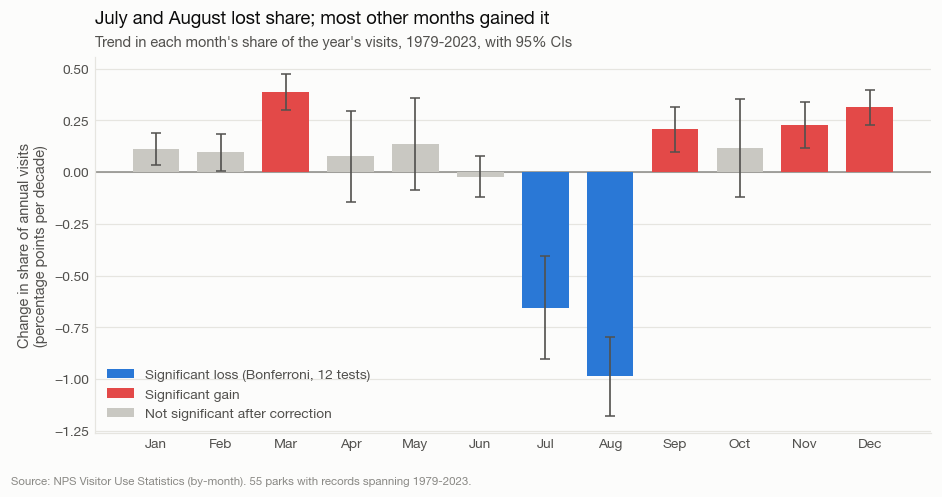

In [4]:
month_share = national.div(national.sum(axis=1), axis=0)
month_fits = pd.DataFrame({m: npdata.trend(month_share[m]) for m in range(1, 13)}).T
for col in ["slope", "ci_low", "ci_high"]:
    month_fits[col] *= 100
month_fits["significant"] = month_fits.p_value < 0.05 / 12   # Bonferroni for twelve tests

MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
fig, ax = npviz.new_figure(8.6, 4.3)
colors = [npviz.RED if (s and v > 0) else (npviz.BLUE if s else npviz.EMPHASIS_GRAY)
          for s, v in zip(month_fits.significant, month_fits.slope)]
ax.bar(range(12), month_fits.slope, color=colors, width=0.72, zorder=3)
ax.errorbar(range(12), month_fits.slope,
            yerr=[month_fits.slope - month_fits.ci_low, month_fits.ci_high - month_fits.slope],
            fmt="none", ecolor=npviz.TEXT_SECONDARY, elinewidth=1.1, capsize=3, zorder=4)
ax.axhline(0, color=npviz.TEXT_MUTED, lw=1, zorder=2)
ax.set_xticks(range(12))
ax.set_xticklabels(MONTHS)
ax.set_ylabel("Change in share of annual visits\n(percentage points per decade)")
ax.legend(handles=[Patch(facecolor=npviz.BLUE, label="Significant loss (Bonferroni, 12 tests)"),
                   Patch(facecolor=npviz.RED, label="Significant gain"),
                   Patch(facecolor=npviz.EMPHASIS_GRAY, label="Not significant after correction")], loc="lower left")
npviz.title(ax, "July and August lost share; most other months gained it",
            "Trend in each month's share of the year's visits, 1979-2023, with 95% CIs")
npviz.source_note(fig, "Source: NPS Visitor Use Statistics (by-month). 55 parks with records spanning 1979-2023.")
npviz.save(fig, "draft_02_month_shares")
plt.tight_layout()
plt.show()

In [5]:
month_fits[["slope", "ci_low", "ci_high", "p_value"]].set_axis(MONTHS).round(3)

,slope,ci_low,ci_high,p_value
Jan,0.110,0.033,0.186,0.005
Feb,0.096,0.006,0.185,0.037
Mar,0.386,0.297,0.475,0.000
Apr,0.076,-0.143,0.294,0.496
May,0.135,-0.087,0.357,0.233
Jun,-0.022,-0.123,0.078,0.667
Jul,-0.656,-0.904,-0.407,0.000
Aug,-0.986,-1.177,-0.796,0.000
Sep,0.206,0.097,0.315,0.000
Oct,0.116,-0.118,0.351,0.331


**Figure 2.** Trend in each month's share of annual visits, in percentage points per decade with 95% confidence intervals. Colour marks trends that remain significant after a Bonferroni correction for twelve tests. The twelve trends sum to zero by construction.

The decline sits in the core of the peak. August lost 0.99 points per decade and July 0.66, while June did not change (−0.02, not significant). The share those two months gave up is spread across the rest of the year. March gained most (+0.39), followed by December (+0.31), November (+0.23) and September (+0.21), all significant after correcting for twelve tests. January (+0.11) and February (+0.10) also rose, but their p-values of 0.005 and 0.037 do not survive that correction, and April, May and October rose by amounts we cannot distinguish from zero. In this data, de-seasonalization means the July–August peak has flattened.

## Elaboration

**Does the result depend on how we measured it?** We refit the trend five more ways, each changing one decision. One gives each park equal weight instead of pooling visits. One drops the years when parks were closed for part of the year: 2013, for the October shutdown, and 2020 and 2021, for the pandemic. One handles zero-visit months. Most of these are genuine winter closures, such as at Isle Royale, but some are missing reports: the data essay warns about this, and Katmai records zero for every month of 1995. Rather than judge each zero, we drop every park that has any, which keeps the panel balanced at 26 parks carrying 57% of visits. Two change the summer window, to a narrower July–August and a wider May–September.

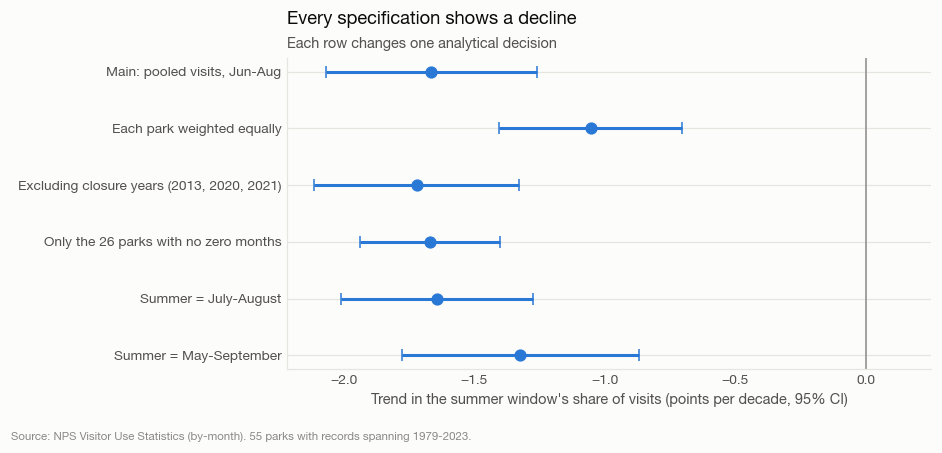

In [6]:
def window_share(matrix, months):
    return matrix[months].sum(axis=1) / matrix.sum(axis=1)

# drop whole parks, not park-years, so the panel stays balanced
no_zero = df[~df.ParkName.isin(df[df.ZeroMonth].ParkName.unique())]
specs = {
    "Main: pooled visits, Jun-Aug": fit,
    "Each park weighted equally": npdata.trend(park_share.groupby(level="Year").mean()),
    "Excluding closure years (2013, 2020, 2021)": npdata.trend(summer.drop(index=[2013, 2020, 2021])),
    f"Only the {no_zero.ParkName.nunique()} parks with no zero months": npdata.trend(
        npdata.summer_share(npdata.monthly_matrix(no_zero, ["Year"]))),
    "Summer = July-August": npdata.trend(window_share(national, [7, 8])),
    "Summer = May-September": npdata.trend(window_share(national, [5, 6, 7, 8, 9])),
}
names = list(specs)
est = [specs[k].slope * 100 for k in names]
lo = [(specs[k].slope - specs[k].ci_low) * 100 for k in names]
hi = [(specs[k].ci_high - specs[k].slope) * 100 for k in names]

fig, ax = npviz.new_figure(8.6, 3.9)
ax.errorbar(est, range(len(names)), xerr=[lo, hi], fmt="o", color=npviz.BLUE, ecolor=npviz.BLUE,
            elinewidth=2, capsize=4, markersize=7, zorder=3)
ax.axvline(0, color=npviz.TEXT_MUTED, lw=1)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlim(right=0.25)
ax.set_xlabel("Trend in the summer window's share of visits (points per decade, 95% CI)")
npviz.title(ax, "Every specification shows a decline", "Each row changes one analytical decision")
npviz.source_note(fig, "Source: NPS Visitor Use Statistics (by-month). 55 parks with records spanning 1979-2023.")
npviz.save(fig, "draft_03_specifications")
plt.tight_layout()
plt.show()

In [7]:
park_totals = npdata.monthly_matrix(df, ["ParkName", "Year"]).sum(axis=1).unstack("Year")
weights_7983 = park_totals.loc[:, 1979:1983].sum(axis=1) / park_totals.loc[:, 1979:1983].sum().sum()
weights_1923 = park_totals.loc[:, 2019:2023].sum(axis=1) / park_totals.loc[:, 2019:2023].sum().sum()
for label, w in [("1979-83", weights_7983), ("2019-23", weights_1923)]:
    fixed_weight = park_share.unstack("Year").mul(w, axis=0).sum()
    print(f"fixed {label} weights: {npdata.trend(fixed_weight).slope * 100:+.2f} pp/decade")
print(f"park fixed effects: {npdata.panel_trend(park_share).slope * 100:+.3f} (equal-weight: {npdata.trend(park_share.groupby(level='Year').mean()).slope * 100:+.3f})")

pd.DataFrame({k: specs[k][["slope", "ci_low", "ci_high", "p_value"]] * [100, 100, 100, 1]
              for k in names}).T.round(3)

fixed 1979-83 weights: -1.43 pp/decade
fixed 2019-23 weights: -1.57 pp/decade
park fixed effects: -1.062 (equal-weight: -1.054)


,slope,ci_low,ci_high,p_value
"Main: pooled visits, Jun-Aug",-1.664,-2.068,-1.260,0.0
Each park weighted equally,-1.054,-1.404,-0.704,0.0
"Excluding closure years (2013, 2020, 2021)",-1.721,-2.112,-1.330,0.0
Only the 26 parks with no zero months,-1.669,-1.937,-1.402,0.0
Summer = July-August,-1.642,-2.009,-1.275,0.0
Summer = May-September,-1.323,-1.776,-0.871,0.0


**Figure 3.** The trend under six specifications, in percentage points per decade with 95% confidence intervals.

Every specification gives a decline, and every interval excludes zero. Dropping the closure years or the parks with zero months barely changes the estimate (−1.72 and −1.67). The weighting matters more. Weighting parks equally gives −1.05, smaller than the pooled −1.66. A park fixed-effects panel gives the same estimate, as it must in a balanced panel, so we do not count it as a separate check. Most of the gap is park size. Holding each park's weight fixed at its share of visits still gives −1.43 with 1979–83 weights and −1.57 with 2019–23 weights, so the most visited parks moved away from summer faster than the typical park. The remaining 0.1 to 0.2 points, depending on the base period, comes from visits shifting toward parks that were less summer-heavy to begin with. The pooled and equal-weighted numbers answer different questions: the pooled one describes the visiting public, the equal-weighted one the average park. We quote the pooled figure because the claim is about how people visit. The alternative summer windows cannot be compared with the main estimate in size, since a two-month and a five-month window start from different shares, but both decline.

**Does it hold across parks?** A pooled trend could be carried by a few large parks, so we fit the same trend separately for each one.

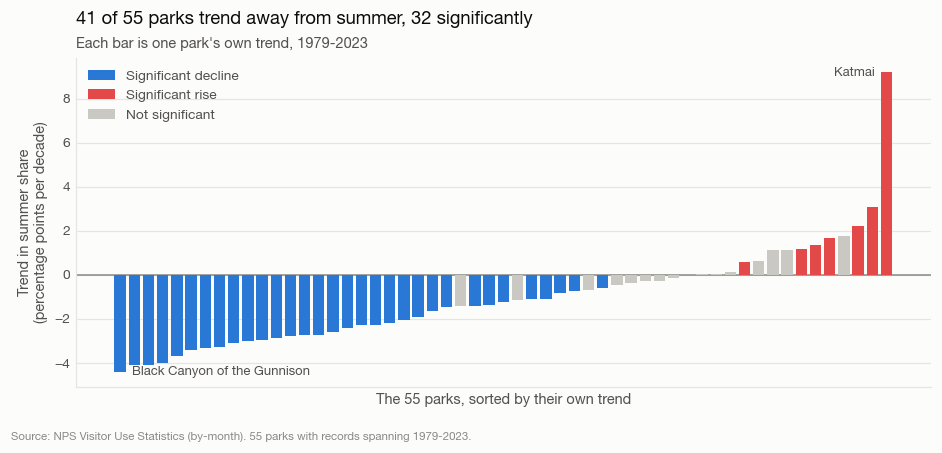

In [8]:
per_park = npdata.park_trends(park_share)
per_park["pp"] = per_park.slope * 100
per_park = per_park.sort_values("pp")
colors = [npviz.RED if (s and v > 0) else (npviz.BLUE if s else npviz.EMPHASIS_GRAY)
          for s, v in zip(per_park.significant, per_park.pp)]

fig, ax = npviz.new_figure(8.6, 3.9)
ax.bar(range(len(per_park)), per_park.pp, color=colors, width=0.8, zorder=3)
ax.axhline(0, color=npviz.TEXT_MUTED, lw=1)
ax.set_xticks([])
ax.set_xlabel(f"The {len(per_park)} parks, sorted by their own trend")
ax.set_ylabel("Trend in summer share\n(percentage points per decade)")
for park in [per_park.index[0], per_park.index[-1]]:
    i = per_park.index.get_loc(park)
    v = per_park.loc[park, "pp"]
    ax.annotate(park.replace(" NP & PRES", "").replace(" NP", ""), (i, v),
                xytext=(8 if i == 0 else -8, 0), textcoords="offset points",
                ha="left" if i == 0 else "right", va="center", fontsize=8.5, color=npviz.TEXT_SECONDARY)
ax.legend(handles=[Patch(facecolor=npviz.BLUE, label="Significant decline"),
                   Patch(facecolor=npviz.RED, label="Significant rise"),
                   Patch(facecolor=npviz.EMPHASIS_GRAY, label="Not significant")], loc="upper left")
npviz.title(ax, f"{int((per_park.pp < 0).sum())} of {len(per_park)} parks trend away from summer, "
            f"{int(((per_park.pp < 0) & per_park.significant).sum())} significantly",
            "Each bar is one park's own trend, 1979-2023")
npviz.source_note(fig, "Source: NPS Visitor Use Statistics (by-month). 55 parks with records spanning 1979-2023.")
npviz.save(fig, "draft_04_park_trends")
plt.tight_layout()
plt.show()

In [9]:
print(f"declining {int((per_park.pp < 0).sum())}, significant declines "
      f"{int(((per_park.pp < 0) & per_park.significant).sum())}, significant rises "
      f"{int(((per_park.pp > 0) & per_park.significant).sum())}")

region_share = npdata.summer_share(npdata.monthly_matrix(df, ["Region", "Year"])).dropna()
regions = pd.DataFrame({r: npdata.trend(g.droplevel(0)) for r, g in region_share.groupby(level=0)}).T
regions[["slope", "ci_low", "ci_high"]] *= 100
regions["parks"] = df.groupby("Region").ParkName.nunique()
print(regions[["parks", "slope", "ci_low", "ci_high", "p_value"]].sort_values("slope").round(3))
for r in ["Alaska", "Northeast"]:
    members = df[df.Region == r].ParkName.unique()
    print(r, per_park.loc[members, ["pp", "p_value"]].round(3).to_dict("index"))

declining 41, significant declines 32, significant rises 7
               parks  slope  ci_low  ci_high  p_value
Intermountain     19 -2.792  -3.359   -2.225    0.000
Southeast          6 -2.120  -2.455   -1.786    0.000
Midwest            9 -1.749  -2.627   -0.871    0.000
Alaska             3 -1.729  -2.452   -1.006    0.000
Pacific West      16 -1.230  -1.658   -0.802    0.000
Northeast          2  0.860   0.028    1.692    0.043
Alaska {'Denali NP & PRES': {'pp': -0.671, 'p_value': 0.182}, 'Glacier Bay NP & PRES': {'pp': -3.678, 'p_value': 0.0}, 'Katmai NP & PRES': {'pp': 9.187, 'p_value': 0.0}}
Northeast {'Acadia NP': {'pp': 1.143, 'p_value': 0.113}, 'Shenandoah NP': {'pp': -0.606, 'p_value': 0.031}}


**Figure 4.** The summer-share trend for each of the 55 parks. Blue bars are significant declines, red bars significant rises and grey bars not significant at *p* < 0.05.

Forty-one of the 55 parks trend downward, 32 of them significantly. Seven rise significantly. With 55 separate tests at the 5% level, about three significant results would be expected by chance alone, far fewer than the 39 we see. The decline is the typical pattern rather than the product of a few big parks. By region, the four regions with at least six parks all declined: Intermountain (19 parks) at −2.79 points per decade, Southeast (6) at −2.12, Midwest (9) at −1.75 and Pacific West (16) at −1.23. Alaska (3 parks) and the Northeast (2) are too small to read as regions. Alaska's parks split between Glacier Bay's steep decline and Katmai's steep rise, the largest in the panel, and the Northeast's slight rise comes from Acadia, partly its own rise, which is not significant, and partly its growing share of the region's visits, while Shenandoah de-seasonalized.

In [10]:
start_years = pd.Series({y: npdata.trend(summer[summer.index >= y]).slope * 100 for y in range(1979, 2005)})
rolling = pd.Series({e: npdata.trend(summer[(summer.index > e - 20) & (summer.index <= e)]).slope * 100
                     for e in range(1998, 2024)})
print("start-year slopes range", round(start_years.max(), 2), "to", round(start_years.min(), 2))
print("rolling 20-year slopes:", rolling.loc[[1998, 2005, 2010, 2015, 2019, 2023]].round(2).to_dict())
print("fit through 2019 only:", round(npdata.trend(summer.loc[:2019]).slope * 100, 2))
print("summer share 2018-2023:", summer.loc[2018:2023].round(3).to_dict(),
      "| lowest pre-2020:", round(summer.loc[:2019].min(), 3))

start-year slopes range -1.44 to -2.17
rolling 20-year slopes: {1998: -2.29, 2005: -1.73, 2010: -1.28, 2015: -0.08, 2019: -0.63, 2023: -2.17}
fit through 2019 only: -1.46
summer share 2018-2023: {2018: 0.432, 2019: 0.441, 2020: 0.441, 2021: 0.419, 2022: 0.401, 2023: 0.411} | lowest pre-2020: 0.432


**Has the pace been steady?** The direction does not depend on where the series starts: fitting from any start year between 1979 and 2004 gives a slope between −1.44 and −2.17 points per decade. The pace does vary. A trailing 20-year window gives −2.29 for 1979–1998 but only −0.08 for 1996–2015. Part of that flatness is the 2013 shutdown spike near the end of the window; without 2013 the slope for 1996–2015 is −0.37, still far slower than the long-run trend. The share fell again after 2015. The three lowest summer shares on record are 2021, 2022 and 2023, at 40–42%, all below the pre-pandemic low of 43.2% in 2018, while 2020 itself was an ordinary 44%. Fitting only through 2019 gives −1.46, so these recent years steepen the estimate but do not create the trend. Whether they mark a lasting step down cannot be judged from data that ends in 2023.

## Discussion

**What is surprising, and what is not.** That the summer share fell is not surprising on its own. How it fell is less obvious. Summer visits grew 26%, and the share fell only because the rest of the year grew faster. A reader who saw only the share could conclude that parks are quieter in summer than they used to be, and that would be wrong. The loss is also specific: it came out of July and August while June held steady. The unsurprising part is a useful sanity check. Summer still dominates: in 2019–23, 42% of visits fell in three months, about 1.7 times what an evenly spread year would give.

**What the data cannot tell us.** This dataset records when counted visits happen, not why. We cannot separate a change in when people choose to visit from a change in when parks let them, since roads, campgrounds or visitor centres staying open for more of the year would produce the same pattern. The data essay also explains that visits are estimated with park-specific formulas that have changed over time. If off-season counting became more complete, part of the trend would be measurement rather than behaviour. Neither possibility can be tested with this file. For the same reason we do not interpret why March gained the most.

**Generalizability.** *To future years:* the direction is a safer bet than the rate. The trend is negative from every start year, but its pace has swung from −2.3 to a small fraction of that and back, so extending −1.66 points per decade forward would be unwise. *To other parks:* the pattern is broad but not universal, and strongest in the Intermountain and Southeast regions. The eight parks left out of the panel are mostly remote Alaska parks, 1.8% of all visits, and the three Alaska parks inside the panel disagree among themselves, so those excluded parks could go either way. *To other kinds of sites:* the file covers only units designated National Park, not monuments, seashores or historic sites, so we would not extend the claim to them. *To visitors generally:* the data counts recreation visits only. Per the data essay these exclude commuters, staff and researchers, and park visitors are not representative of the U.S. population. The claim describes when counted park visits happen, not how all Americans use these places.

## References

Walsh, Melanie, and Os Keyes. 2024. "U.S. National Park Visit Data (1979–2024)." Edited by Melanie Walsh, Anna Preus, Amardeep Singh, Sylvia Fernandez, and Miriam Posner. *Responsible Datasets in Context*, June 1. https://www.responsible-datasets-in-context.com/posts/np-data/ (by-month dataset and data essay).

Office of Management and Budget. 2013. *Impacts and Costs of the October 2013 Federal Government Shutdown.* Executive Office of the President. https://obamawhitehouse.archives.gov/sites/default/files/omb/reports/impacts-and-costs-of-october-2013-federal-government-shutdown-report.pdf

National Park Service. Visitor Use Statistics. https://irma.nps.gov/Stats/